In [1]:
# Set the root path to your project directory
import pathlib

root = pathlib.Path(r"c:\Users\26293\Desktop\WORK\emhass_git\emhass")
print(root)
print(list((root / "data").glob("*")))  # List files in the data folder

c:\Users\26293\Desktop\WORK\emhass_git\emhass
[WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/actionLogs.txt'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/adjust_pv_regressor.pkl'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/cached-open-meteo-forecast.json'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_load_cost_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_load_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_prod_price_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_weather_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-data-prep-input-data.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-data-prep-output-data.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-ad

In [2]:
import pickle

# Load the pickle file
with open(root / "data" / "long_train_data.pkl", "rb") as inp:
    data = pickle.load(inp)

df_final, days_list, var_list, ha_config = data
print("days_list:", days_list)
print("var_list:", var_list)
print("ha_config:", ha_config)

days_list: DatetimeIndex(['2024-02-28 21:00:00+00:00', '2024-02-29 21:00:00+00:00',
               '2024-03-01 21:00:00+00:00', '2024-03-02 21:00:00+00:00',
               '2024-03-03 21:00:00+00:00', '2024-03-04 21:00:00+00:00',
               '2024-03-05 21:00:00+00:00', '2024-03-06 21:00:00+00:00',
               '2024-03-07 21:00:00+00:00', '2024-03-08 21:00:00+00:00',
               ...
               '2025-02-18 21:00:00+00:00', '2025-02-19 21:00:00+00:00',
               '2025-02-20 21:00:00+00:00', '2025-02-21 21:00:00+00:00',
               '2025-02-22 21:00:00+00:00', '2025-02-23 21:00:00+00:00',
               '2025-02-24 21:00:00+00:00', '2025-02-25 21:00:00+00:00',
               '2025-02-26 21:00:00+00:00', '2025-02-27 21:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=366, freq='D')
var_list: ['sensor.power_load_no_var_loads', 'sensor.power_photovoltaics', 'sensor.p_pv_forecast']
ha_config: {'country': 'FR', 'currency': 'EUR', 'elevation': 4807, 'latitud

C:\Users\26293\AppData\Local\Temp\ipykernel_32664\3795601157.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(inp)


In [3]:
print(df_final.columns)

Index(['sensor.power_load_no_var_loads', 'sensor.power_photovoltaics',
       'sensor.p_pv_forecast'],
      dtype='object')


In [4]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import datetime as dt
import math
from sklearn.preprocessing import MinMaxScaler

In [5]:
train_start_dt = '2024-02-28 21:00:00+00:00'
test_start_dt = '2025-02-25 22:30:00+00:00'

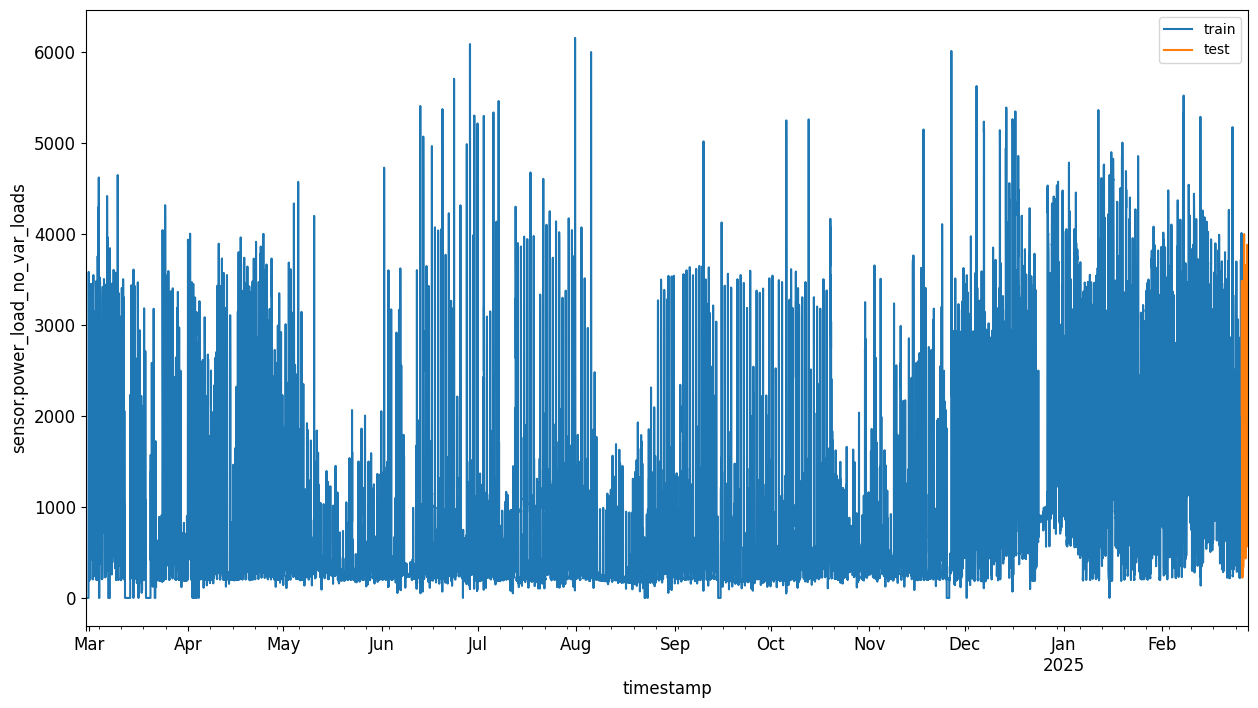

In [6]:
df_final = df_final.fillna(0)
df_final[(df_final.index < test_start_dt) & (df_final.index >= train_start_dt)][['sensor.power_load_no_var_loads']].rename(columns={'sensor.power_load_no_var_loads':'train'}) \
    .join(df_final[test_start_dt:][['sensor.power_load_no_var_loads']].rename(columns={'sensor.power_load_no_var_loads':'test'}), how='outer') \
    .plot(y=['train', 'test'], figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('sensor.power_load_no_var_loads', fontsize=12)
plt.show()

In [7]:
train = df_final.copy()[(df_final.index >= train_start_dt) & (df_final.index < test_start_dt)][['sensor.power_load_no_var_loads']]
test = df_final.copy()[df_final.index >= test_start_dt][['sensor.power_load_no_var_loads']]

print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

Training data shape:  (17427, 1)
Test data shape:  (97, 1)


In [8]:
scaler = MinMaxScaler()
train['sensor.power_load_no_var_loads'] = scaler.fit_transform(train)

In [9]:
test['sensor.power_load_no_var_loads'] = scaler.transform(test)

In [10]:
# Converting to numpy arrays
train_data = train.values
test_data = test.values

In [11]:
timesteps=5

In [12]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] for i in range(0,len(train_data)-timesteps+1)])[:,:,0]
train_data_timesteps.shape

(17423, 5)

In [13]:
test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] for i in range(0,len(test_data)-timesteps+1)])[:,:,0]
test_data_timesteps.shape

(93, 5)

In [14]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(17423, 4) (17423, 1)
(93, 4) (93, 1)


In [15]:
model = SVR(kernel='rbf',gamma=0.5, C=10, epsilon = 0.05)

In [16]:
model.fit(x_train, y_train[:,0])

,kernel,'rbf'
,degree,3
,gamma,0.5
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.05
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [17]:
SVR(C=10, cache_size=200, coef0=0.0, degree=3, epsilon=0.05, gamma=0.5,
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

,kernel,'rbf'
,degree,3
,gamma,0.5
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.05
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [18]:
y_train_pred = model.predict(x_train).reshape(-1,1)
y_test_pred = model.predict(x_test).reshape(-1,1)

print(y_train_pred.shape, y_test_pred.shape)

(17423, 1) (93, 1)


In [19]:
# Scaling the predictions
y_train_pred = scaler.inverse_transform(y_train_pred)
y_test_pred = scaler.inverse_transform(y_test_pred)

print(len(y_train_pred), len(y_test_pred))
# Scaling the original values
y_train = scaler.inverse_transform(y_train)
y_test = scaler.inverse_transform(y_test)

print(len(y_train), len(y_test))

17423 93
17423 93


In [20]:
train_timestamps = df_final[(df_final.index < test_start_dt) & (df_final.index >= train_start_dt)].index[timesteps-1:]
test_timestamps = df_final[test_start_dt:].index[timesteps-1:]

print(len(train_timestamps), len(test_timestamps))

17423 93


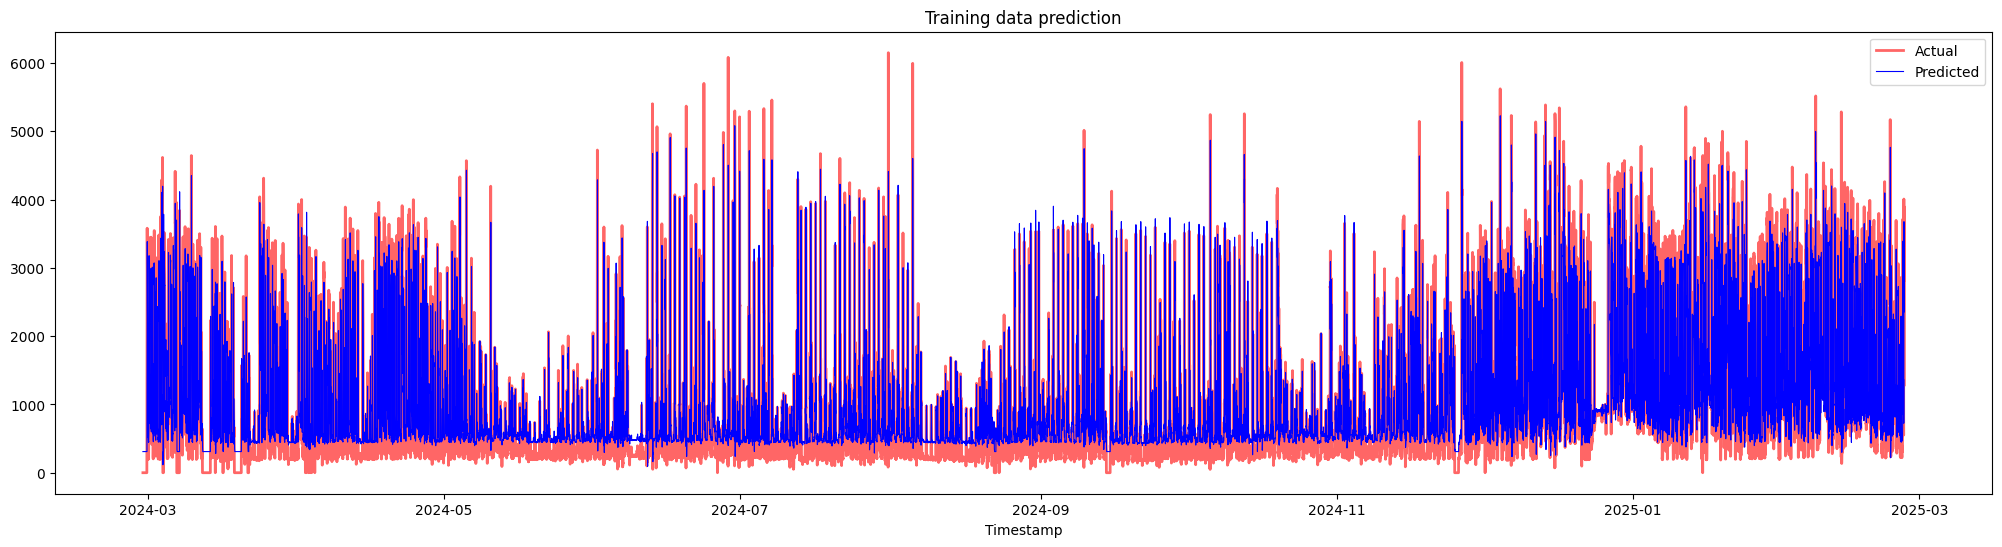

In [21]:
plt.figure(figsize=(25,6))
plt.plot(train_timestamps, y_train, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(train_timestamps, y_train_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('Timestamp')
plt.title("Training data prediction")
plt.show()

In [22]:
from sklearn.metrics import r2_score

# For training data
r2_train = r2_score(y_train, y_train_pred)
print("Train R²:", r2_train)

# For test data
r2_test = r2_score(y_test, y_test_pred)
print("Test R²:", r2_test)

Train R²: 0.5889147405189051
Test R²: 0.49780177894905175


Test data range: 2025-02-26 00:30:00+00:00 to 2025-02-27 22:30:00+00:00
                               actual   predicted
timestamp                                        
2025-02-26 00:30:00+00:00  266.457207  864.099933
2025-02-26 01:00:00+00:00  232.014222  571.213775
2025-02-26 01:30:00+00:00  397.819111  518.935982
2025-02-26 02:00:00+00:00  261.148156  556.123867
2025-02-26 02:30:00+00:00  222.689167  481.793866


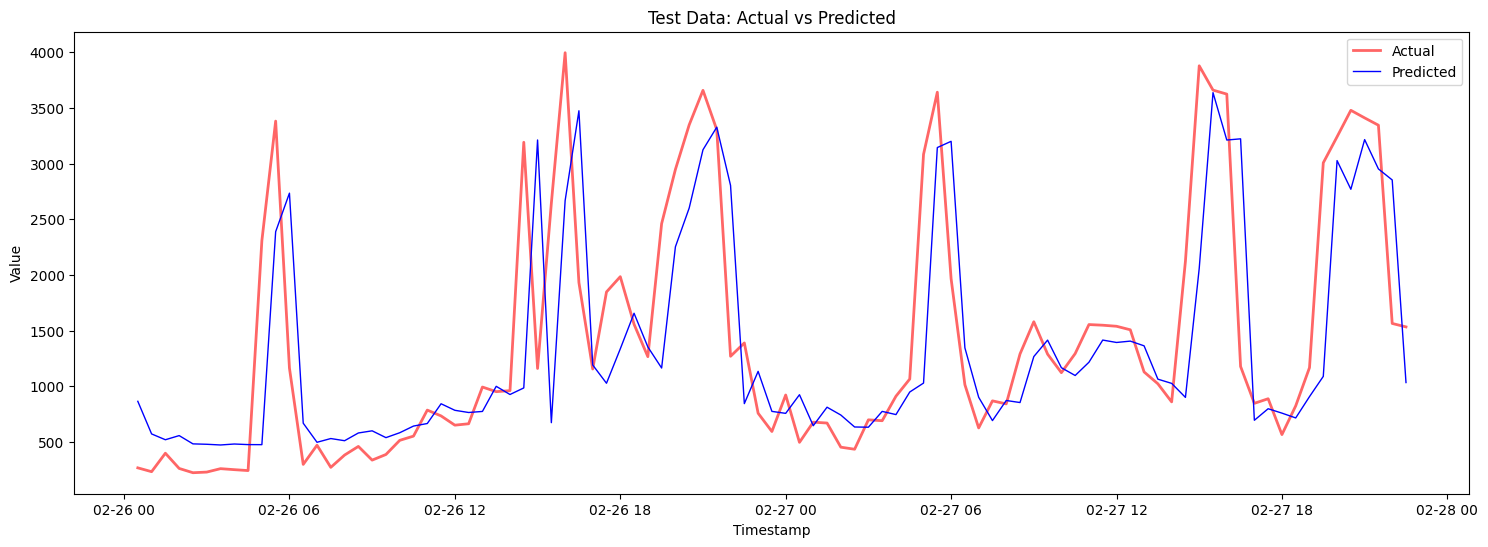

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame for test actual and predicted values
df_test_results = pd.DataFrame({
    'timestamp': test_timestamps,
    'actual': y_test.flatten(),
    'predicted': y_test_pred.flatten()
})
df_test_results.set_index('timestamp', inplace=True)
# Test data range
test_range_min = df_test_results.index.min()
test_range_max = df_test_results.index.max()
print(f"Test data range: {test_range_min} to {test_range_max}")
# Display the table
print(df_test_results.head())

# Plot actual vs predicted for test data
plt.figure(figsize=(18,6))
plt.plot(df_test_results.index, df_test_results['actual'], label='Actual', color='red', linewidth=2, alpha=0.6)
plt.plot(df_test_results.index, df_test_results['predicted'], label='Predicted', color='blue', linewidth=1)
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Test Data: Actual vs Predicted')
plt.legend()